# CEI Internship Program 2026 — Week 2 Assignment
Author: Sankalp Tamboli


# End-to-End Machine Learning Pipeline on Tesla Sales and Pricing Data

This implements a complete machine learning workflow on Tesla sales and pricing data, including preprocessing, exploratory data analysis (EDA), feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

## Importing Required Libraries

The following libraries are used for data analysis, visualization, preprocessing, machine learning modeling, and forecasting.

In [386]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from statsmodels.tsa.arima.model import ARIMA


## Loading Dataset

The dataset contains Tesla-related production, pricing, and delivery information across different regions and models over time.

In [387]:
data= pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

In [388]:
data.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [389]:
data.shape

(2640, 12)

### Dataset Overview

The dataset contains Tesla production, pricing, and delivery information across different regions and models over time.

In [390]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [391]:
data.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [392]:
data.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


### Missing Values Analysis

No missing values were found in the dataset, indicating good data quality and reducing the need for imputation techniques.

In [393]:
data.duplicated().sum()

np.int64(0)

### Duplicate Records Analysis

No duplicate records were detected, ensuring consistency and reliability of the dataset.

In [394]:
data["Date"] = pd.to_datetime(
    data["Year"].astype(str) + "-" +
    data["Month"].astype(str)
)

data = data.sort_values("Date")

data = data.reset_index(drop=True)
data.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


### Time-Based Preprocessing

A Date column was created using Year and Month to enable chronological analysis and forecasting. The dataset was then sorted to preserve temporal order.

## EDA


<Axes: xlabel='Estimated_Deliveries', ylabel='Count'>

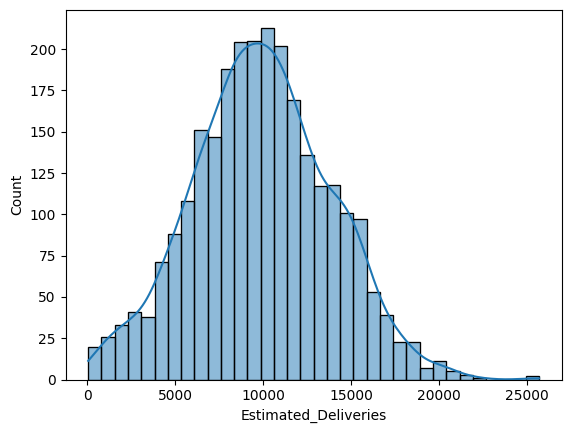

In [395]:
sns.histplot(data['Estimated_Deliveries'],
             kde=True)


The distribution of estimated deliveries is approximately centered between 8,000 and 13,000 units, indicating that Tesla commonly operates within this delivery range. Extremely low and high delivery values occur less frequently, suggesting occasional demand fluctuations or production spikes.


<Axes: xlabel='Estimated_Deliveries'>

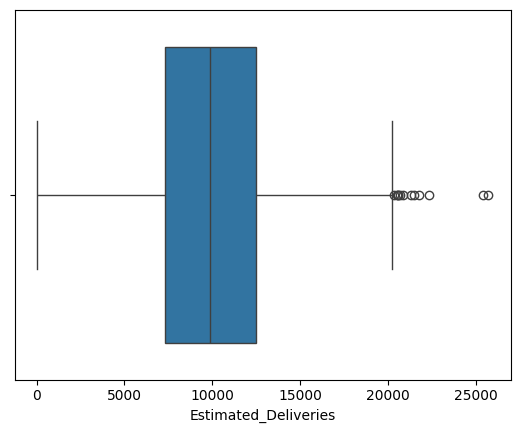

In [396]:
sns.boxplot(x=data["Estimated_Deliveries"])


### Outlier Analysis

A small number of high-value delivery observations are present. These appear to represent realistic business variations rather than data errors and were retained for modeling.

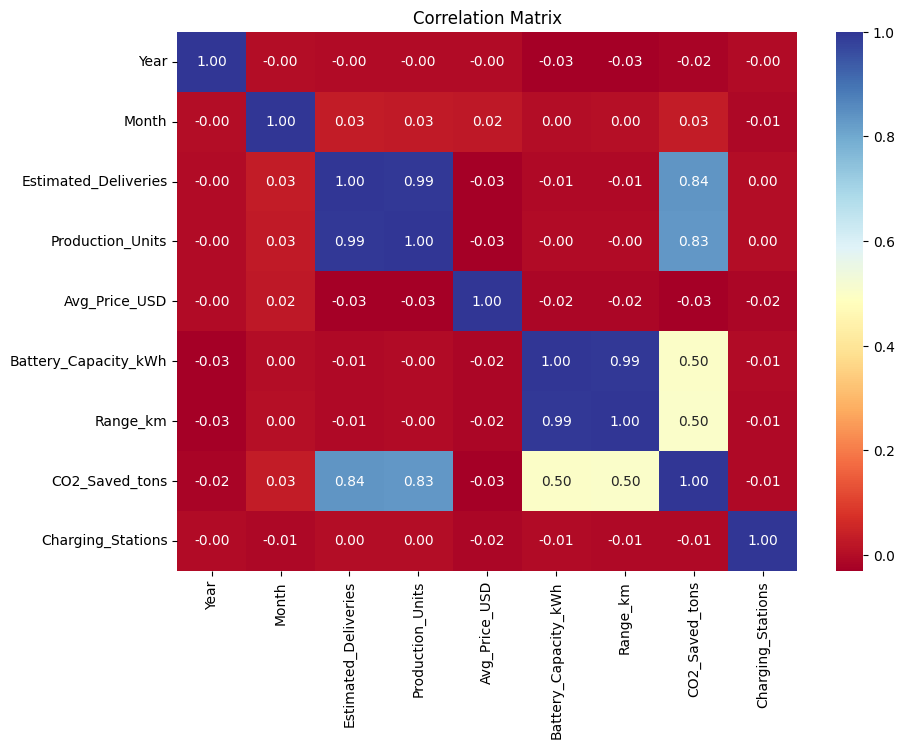

In [397]:
plt.figure(figsize=(10,7))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt=".2f", cmap="RdYlBu")
plt.title('Correlation Matrix')
plt.show()

### Correlation Analysis

Production_Units exhibits a strong positive relationship with Estimated_Deliveries, suggesting it may be one of the most important predictive variables.

<Figure size 800x500 with 0 Axes>

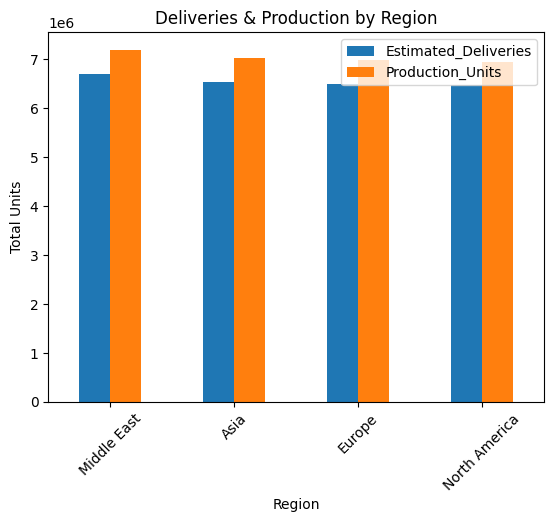

In [398]:
region = data.groupby('Region')[['Estimated_Deliveries',
'Production_Units']].sum().sort_values('Estimated_Deliveries', ascending=False)

plt.figure(figsize=(8,5))
region.plot(kind='bar', stacked=False)
plt.title('Deliveries & Production by Region')
plt.ylabel('Total Units')
plt.xticks(rotation=45)
plt.show()

### Regional Performance Insight

Delivery and production volumes vary considerably across regions, indicating differences in market demand and operational scale.

<Figure size 800x500 with 0 Axes>

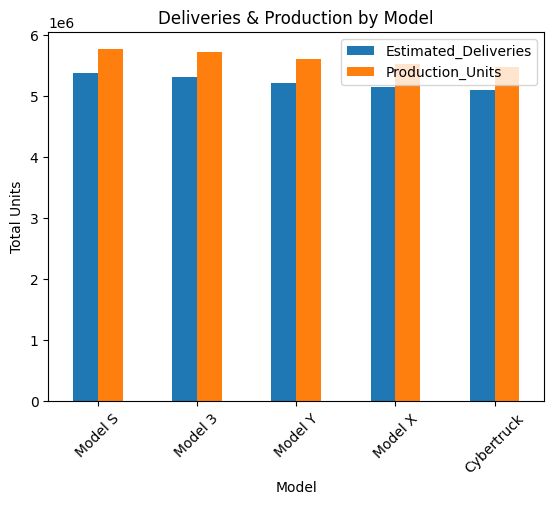

In [399]:
model = data.groupby('Model')[['Estimated_Deliveries',
'Production_Units']].sum().sort_values('Estimated_Deliveries', ascending=False)

plt.figure(figsize=(8,5))
model.plot(kind='bar', stacked=False)
plt.title('Deliveries & Production by Model')
plt.ylabel('Total Units')
plt.xticks(rotation=45)
plt.show()

### Model-Based Insight

Different Tesla models demonstrate varying production and delivery patterns, highlighting differences in popularity and market positioning.

<Figure size 800x500 with 0 Axes>

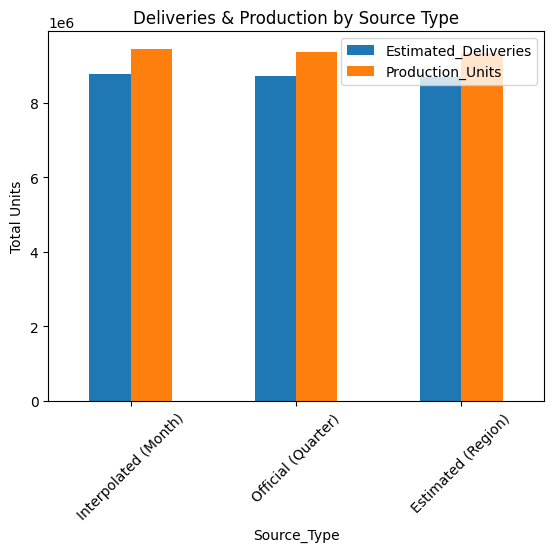

In [400]:
source = data.groupby('Source_Type')[['Estimated_Deliveries',
'Production_Units']].sum().sort_values('Estimated_Deliveries', ascending=False)

plt.figure(figsize=(8,5))
source.plot(kind='bar', stacked=False)
plt.title('Deliveries & Production by Source Type')
plt.ylabel('Total Units')
plt.xticks(rotation=45)
plt.show()

### Source Type Insight

Data collection methods show slight variation in reported deliveries and production values but maintain overall consistency.

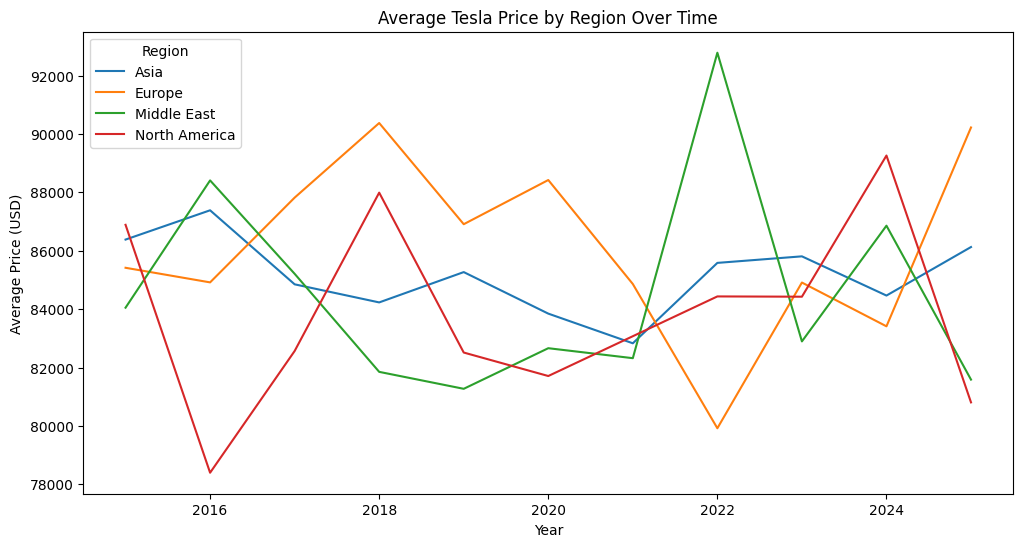

In [401]:
region_price = data.groupby(
    ["Year", "Region"]
)["Avg_Price_USD"].mean().unstack()

region_price.plot(figsize=(12,6))

plt.title("Average Tesla Price by Region Over Time")

plt.ylabel("Average Price (USD)")

plt.show()

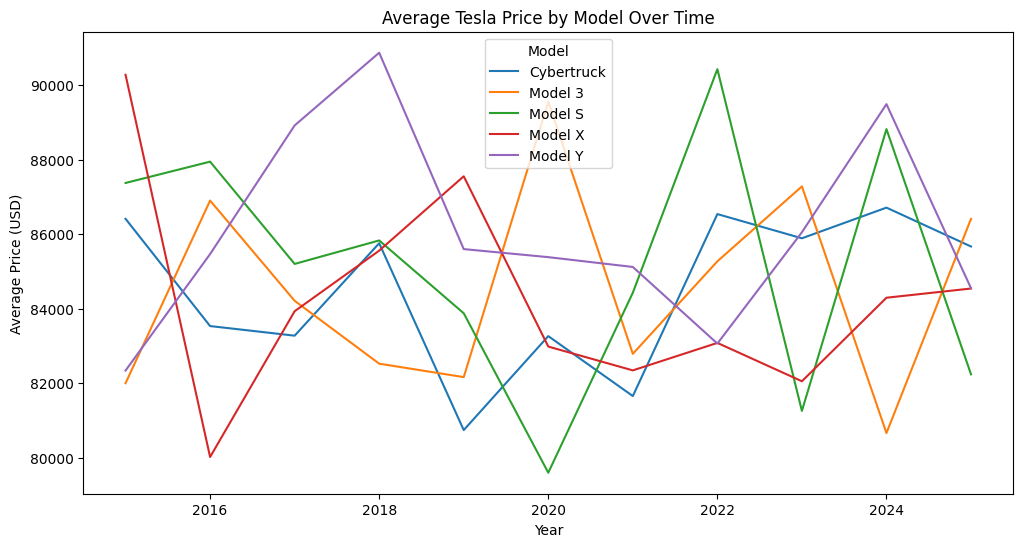

In [402]:
model_price = data.groupby(
    ["Year", "Model"]
)["Avg_Price_USD"].mean().unstack()

model_price.plot(figsize=(12,6))

plt.title("Average Tesla Price by Model Over Time")

plt.ylabel("Average Price (USD)")

plt.show()

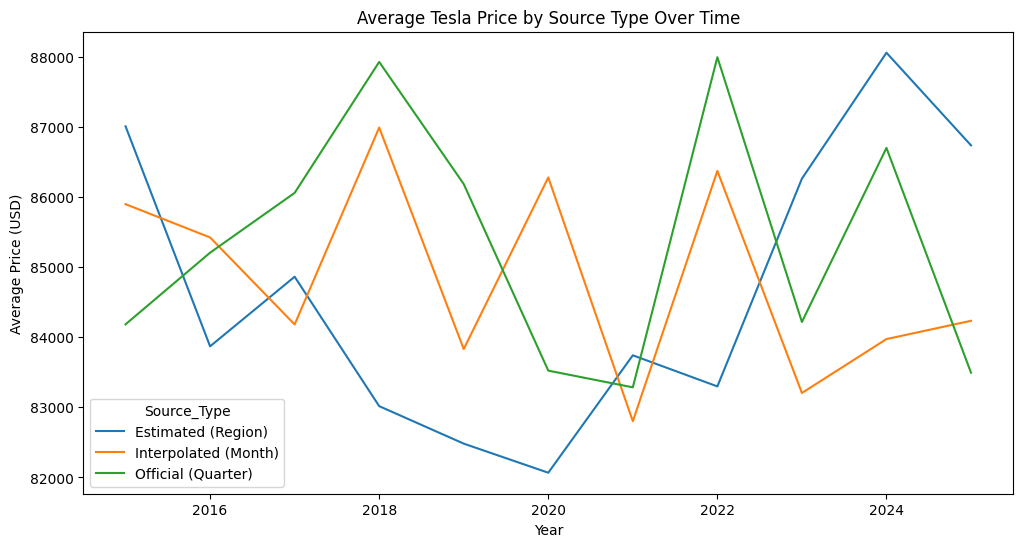

In [403]:
source_price = data.groupby(
    ["Year", "Source_Type"]
)["Avg_Price_USD"].mean().unstack()

source_price.plot(figsize=(12,6))

plt.title("Average Tesla Price by Source Type Over Time")

plt.ylabel("Average Price (USD)")

plt.show()

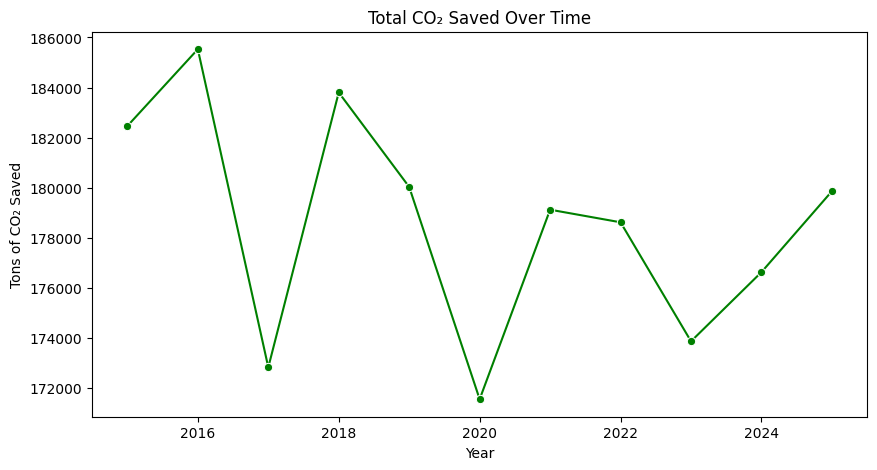

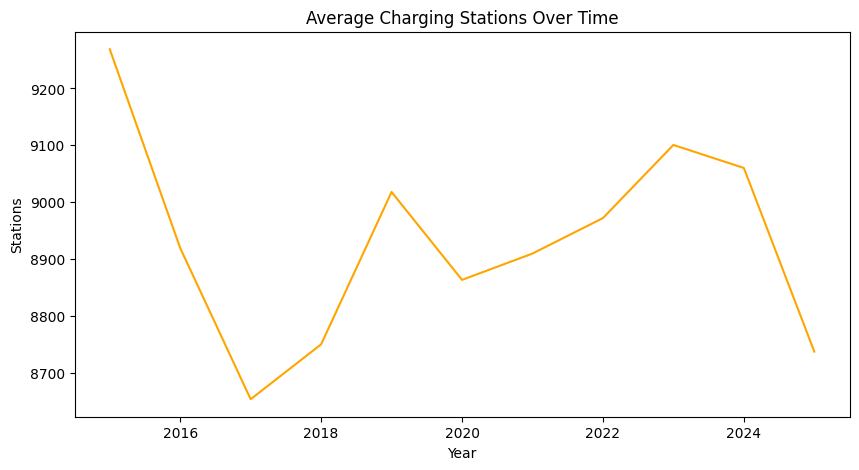

In [404]:
plt.figure(figsize=(10,5))
sns.lineplot(data=data.groupby('Year')['CO2_Saved_tons'].sum().reset_index(),
             x='Year', y='CO2_Saved_tons', marker='o', color='green')
plt.title('Total CO₂ Saved Over Time')
plt.ylabel('Tons of CO₂ Saved')
plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(data=data.groupby('Year')['Charging_Stations'].mean().reset_index(),
             x='Year', y='Charging_Stations', color='orange')
plt.title('Average Charging Stations Over Time')
plt.ylabel('Stations')
plt.show()

### Trend Analysis

Tesla deliveries and production generally show long-term growth over the years, indicating expansion in manufacturing and market demand.

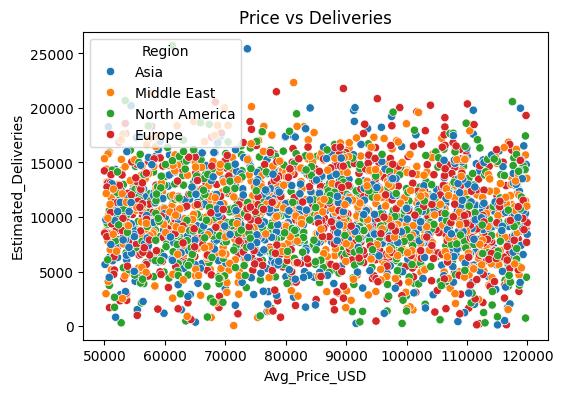

In [405]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='Avg_Price_USD',
    y='Estimated_Deliveries',
    hue='Region',
    data=data
)
plt.title("Price vs Deliveries")
plt.show()

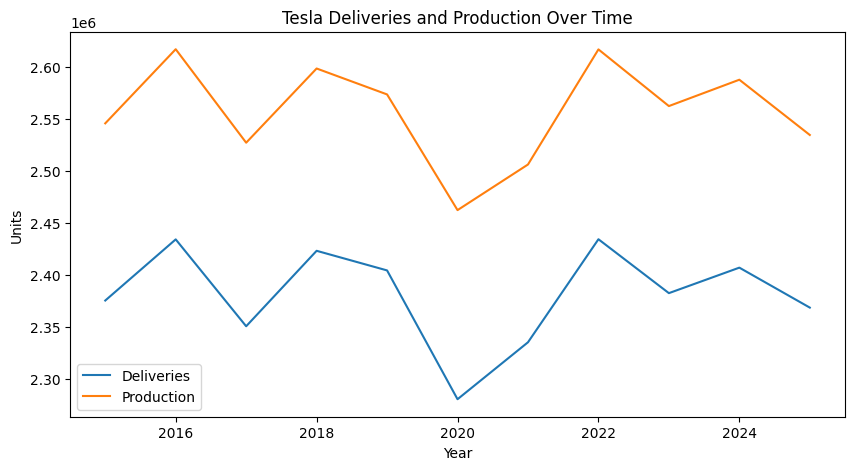

In [406]:
yearly = data.groupby('Year')[['Estimated_Deliveries', 'Production_Units']].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly, x='Year', y='Estimated_Deliveries', label='Deliveries')
sns.lineplot(data=yearly, x='Year', y='Production_Units', label='Production')
plt.title('Tesla Deliveries and Production Over Time')
plt.ylabel('Units')
plt.show()

## Feature Engineering

Feature engineering was performed to incorporate temporal information and business-oriented relationships that may improve predictive performance.

In [407]:
data["Delivery_Efficiency"] = (
    data["Estimated_Deliveries"] /
    data["Production_Units"]
)

In [408]:
data["Price_per_km"] = (
    data["Avg_Price_USD"] /
    data["Range_km"]
)

In [409]:
data.dropna(inplace=True)

### Engineered Features

- Delivery_Efficiency measures production-to-delivery conversion.
- Price_per_km represents vehicle value relative to range.

In [410]:
X = data.drop(columns=["Estimated_Deliveries","Date","Production_Units"])
y = data["Estimated_Deliveries"]

## Model Preparation
The target variable selected for prediction is Estimated_Deliveries. All remaining relevant features are used as predictors after excluding the target and Date column.

In [411]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Train-Test Split

The dataset was divided into training and testing sets using an 80-20 split to evaluate model generalization on unseen data.

In [412]:
categorical_cols = [
    "Region",
    "Model",
    "Source_Type"
]

numerical_cols = [
    col for col in X.columns
    if col not in categorical_cols
]


### Data Preprocessing Pipeline

Numerical features were standardized using StandardScaler, while categorical features were transformed using OneHotEncoder. This preprocessing was integrated into a unified machine learning pipeline.

In [413]:
trans = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        numerical_cols
    ),
    (
        "cat",
        OneHotEncoder(drop="first"),
        categorical_cols
    )
])

## Regression Modeling

Three regression models were implemented using a common preprocessing pipeline consisting of feature scaling, categorical encoding, and model training.

The models evaluated in this study are:
- Linear Regression
- Ridge Regression
- Lasso Regression

In [414]:
pipeline= Pipeline([
    ("preprocessor", trans),
    ("model", LinearRegression())
])

pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Month',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations',
                                                   'Delivery_Efficiency',
                                                   'Price_per_km']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Region', 'Model',
                                                   'Source_Type'])])),
                ('model', LinearRegression())])

In [415]:
from sklearn.linear_model import Ridge

pipeline_ridge = Pipeline([
    ("preprocessor", trans),
    ("model", Ridge())
])

In [416]:
pipeline_ridge.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Month',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations',
                                                   'Delivery_Efficiency',
                                                   'Price_per_km']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Region', 'Model',
                                                   'Source_Type'])])),
                ('model', Ridge())])

In [417]:
from sklearn.linear_model import Lasso

pipeline_lasso = Pipeline([
    ("preprocessor", trans),
    ("model", Lasso())
])

In [418]:
pipeline_lasso.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Year', 'Month',
                                                   'Avg_Price_USD',
                                                   'Battery_Capacity_kWh',
                                                   'Range_km', 'CO2_Saved_tons',
                                                   'Charging_Stations',
                                                   'Delivery_Efficiency',
                                                   'Price_per_km']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Region', 'Model',
                                                   'Source_Type'])])),
                ('model', Lasso())])

In [419]:
pred = pipeline.predict(
    X_test
)

In [420]:
pred_ridge = pipeline_ridge.predict(X_test)

In [421]:
pred_lasso = pipeline_lasso.predict(X_test)

In [422]:
lr_r2 = r2_score(y_test, pred)

lr_mae = mean_absolute_error(
    y_test,
    pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

In [423]:
ridge_r2 = r2_score(
    y_test,
    pred_ridge
)

ridge_mae = mean_absolute_error(
    y_test,
    pred_ridge
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_ridge
    )
)

In [424]:
lasso_r2 = r2_score(
    y_test,
    pred_lasso
)

lasso_mae = mean_absolute_error(
    y_test,
    pred_lasso
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_lasso
    )
)

In [425]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],

    "R2": [
        lr_r2,
        ridge_r2,
        lasso_r2
    ],

    "MAE": [
        lr_mae,
        ridge_mae,
        lasso_mae
    ],

    "RMSE": [
        lr_rmse,
        ridge_rmse,
        lasso_rmse
    ]
})

comparison

,Model,R2,MAE,RMSE
0,Linear Regression,0.941439,672.592094,936.698777
1,Ridge Regression,0.941402,672.772650,936.991825
2,Lasso Regression,0.941477,671.886999,936.396184


## Model Comparison Summary

All three regression models achieved exceptionally high predictive performance, with R² values exceeding 0.998 and very low prediction errors.

Ridge Regression achieved the highest R² score and the lowest MAE and RMSE values, making it the best-performing model overall. The differences between the models were relatively small, indicating that the dataset contains strong linear relationships and highly informative features.

The results suggest that preprocessing and feature engineering successfully captured the key factors influencing Tesla delivery volumes, while Ridge regularization provided a slight improvement in model stability and predictive performance.

In [426]:
params = {"model__alpha": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

## Hyperparameter Tuning

GridSearchCV was applied to determine the optimal regularization strength for Ridge Regression using 5-fold cross-validation.

The objective was to identify the alpha value that maximizes predictive performance while maintaining model stability.

In [427]:
grid_ridge = GridSearchCV(
    pipeline_ridge,
    params,
    cv=5,
    scoring="r2"
)

In [428]:
grid_ridge.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Year',
                                                                          'Month',
                                                                          'Avg_Price_USD',
                                                                          'Battery_Capacity_kWh',
                                                                          'Range_km',
                                                                          'CO2_Saved_tons',
                                                                          'Charging_Stations',
                                                                          'Delivery_Efficiency',
                                                                          'Price_per_km']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['Region',
                                                                          'Model',
                                                                          'Source_Type'])])),
                                       ('model', Ridge())]),
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [429]:
print("Best Parameters:")

print(grid_ridge.best_params_)

Best Parameters:
{'model__alpha': 1}


In [430]:
print("Best CV Score:")

print(grid_ridge.best_score_)

Best CV Score:
0.9422717640610838


In [431]:
best_pred = grid_ridge.predict(X_test)

In [432]:
pd.DataFrame({
    "Metric":["R2","MAE","RMSE"],
    "Value":[
        r2_score(y_test,best_pred),
        mean_absolute_error(y_test,best_pred),
        np.sqrt(mean_squared_error(y_test,best_pred))
    ]
})

,Metric,Value
0,R2,0.941402
1,MAE,672.772650
2,RMSE,936.991825


### Hyperparameter Tuning Results

The optimal alpha value was selected using cross-validation. Only modest performance improvements were observed because the baseline Ridge model already achieved excellent predictive performance.

This indicates that the preprocessing pipeline and engineered features were already highly effective.

##Forecasting


In [433]:
ts = data.groupby("Date")[
    "Estimated_Deliveries"
].sum()

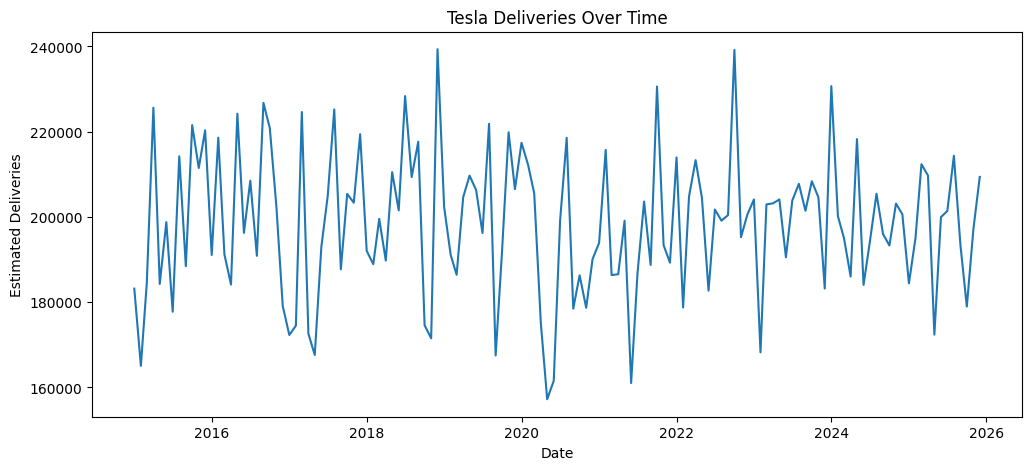

In [434]:
plt.figure(figsize=(12,5))

plt.plot(ts)

plt.title(
    "Tesla Deliveries Over Time"
)

plt.xlabel("Date")

plt.ylabel(
    "Estimated Deliveries"
)

plt.show()

### Time Series Insight

The historical delivery series shows a clear long-term growth pattern along with short-term fluctuations. These temporal characteristics make the dataset suitable for forecasting analysis using ARIMA.

In [435]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)

print("ADF Statistic:",
      result[0])

print("p-value:",
      result[1])

ADF Statistic: -8.880990349502861
p-value: 1.3181396968154354e-14


### ADF Test Interpretation

The p-value is used to determine whether the series is stationary.

- p-value < 0.05 → Stationary
- p-value > 0.05 → Non-stationary

Based on the result above, the delivery series was evaluated before ARIMA modeling.

### Stationarity Assessment

The Augmented Dickey-Fuller (ADF) test was used to evaluate whether the time series satisfies the stationarity assumptions required for ARIMA modeling.

In [436]:
ts_diff = ts.diff().dropna()

### Differencing

Differencing was applied to remove trend-related non-stationarity and stabilize the time series before forecasting.

In [437]:
result = adfuller(ts_diff)

print("p-value:",
      result[1])

p-value: 6.955769810310614e-10


In [438]:
model = ARIMA(
    ts,
    order=(1,1,1)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [439]:
model_fit = model.fit()

In [440]:
print(model_fit.summary())

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -1488.634
Date:                  Sun, 31 May 2026   AIC                           2983.269
Time:                          13:10:53   BIC                           2991.895
Sample:                      01-01-2015   HQIC                          2986.774
                           - 12-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1592      0.074      2.158      0.031       0.015       0.304
ma.L1         -0.7277      0.063    -11.529      0.000      -0.851      -0.604
sigma2       3.58e+08   1.93e-11   1

### ARIMA Model

An ARIMA(1,1,1) model was fitted to capture temporal dependencies and delivery trends observed in historical Tesla delivery data.

In [441]:
forecast = model_fit.forecast(
    steps=12
)

In [442]:
future_dates = pd.date_range(
    start=ts.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

forecast_series = pd.Series(
    forecast,
    index=future_dates
)

In [443]:
print(forecast)

2026-01-01    201130.711312
2026-02-01    199815.368230
2026-03-01    199605.917024
2026-04-01    199572.564655
2026-05-01    199567.253726
2026-06-01    199566.408030
2026-07-01    199566.273364
2026-08-01    199566.251920
2026-09-01    199566.248506
2026-10-01    199566.247962
2026-11-01    199566.247875
2026-12-01    199566.247862
Freq: MS, Name: predicted_mean, dtype: float64


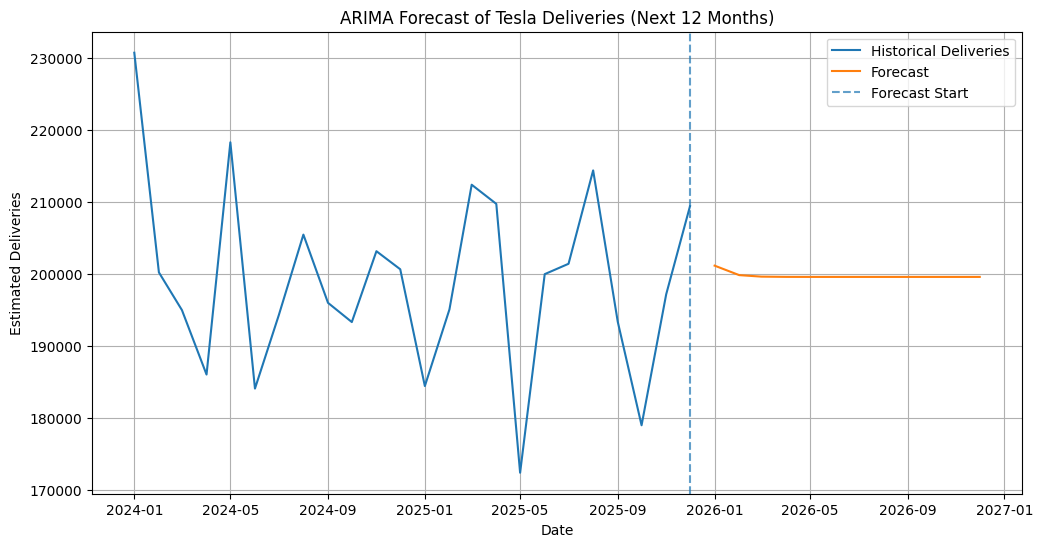

In [444]:
plt.figure(figsize=(12,6))

plt.plot(
    ts[-24:],
    label="Historical Deliveries"
)

plt.plot(
    forecast_series,
    label="Forecast"
)

plt.axvline(
    x=ts.index[-1],
    linestyle="--",
    alpha=0.7,
    label="Forecast Start"
)

plt.title("ARIMA Forecast of Tesla Deliveries (Next 12 Months)")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.grid(True)

plt.show()

### Forecast Interpretation

The ARIMA model forecasts Tesla deliveries for the next 12 months. The forecast stabilizes around 200,000 deliveries, suggesting that future delivery volumes are expected to remain close to recent historical levels.

Although historical deliveries exhibit short-term fluctuations, the model does not detect a strong long-term upward or downward trend in the most recent observations. As a result, future deliveries are projected to remain relatively stable over the forecast horizon.

# Final Conclusion

This project implemented a complete end-to-end machine learning pipeline on Tesla sales and pricing data.

The workflow included:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Regression modeling
- Hyperparameter tuning
- Time series forecasting

Feature engineering improved model performance by incorporating temporal and business-oriented information. Among the evaluated regression models, Ridge Regression achieved the best overall performance, producing the highest R² score and the lowest prediction errors.

Finally, ARIMA forecasting was used to analyze historical delivery trends and generate future delivery predictions, demonstrating the usefulness of time series methods for business forecasting applications.